<div align="center">

#  
# **Master 01 Cybersecurity & Artificial Intelligence**  
## ***Crypto – TP02***  
### `Block Ciphers`
### `Group 02 `
### `ENS : KADDACHE Mohammed El Amine`
</div>


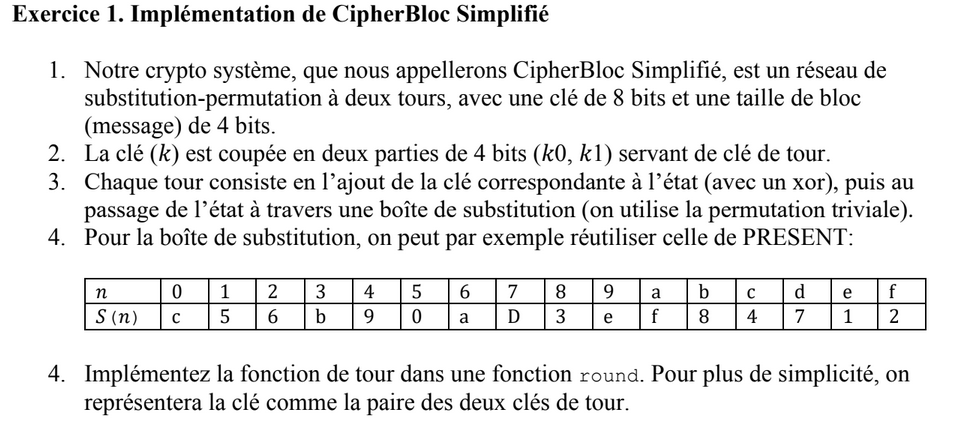

In [2]:
k=0b10011111
m=0b1010

In [3]:
k

159

In [4]:
def keys(k):
  k0=k & 0b1111
  k1=(k >> 4) & 0b1111
  return k1,k0


In [5]:
keys(k)

(9, 15)

In [6]:
sbox=[0xc ,5 ,6 ,0xb ,9 ,0 ,0xa ,0xd ,3 ,0xe ,0xf ,8 ,4 ,7 ,1 ,2]

In [8]:
sbox[0]

12

In [7]:
def round(m,k):
  return sbox[m^k]

In [9]:
round(10,15)

0

In [10]:
def enc(m,k):
  k0,k1=keys(k)
  r1=round(m,k0)
  r2=round(r1,k1)
  return r2

In [13]:
enc(0b1010,0b10010101)

1

In [15]:
for i in range(16):
  print(i,enc(i,0b10110101))

0 7
1 15
2 8
3 10
4 13
5 9
6 6
7 5
8 1
9 11
10 12
11 14
12 3
13 2
14 0
15 4


In [17]:
for i in range(16):
  print(f"{format(i,'04b')} --> {format(enc(i,0b10010101),'04b')}")

0000 --> 1000
0001 --> 1010
0010 --> 0111
0011 --> 1111
0100 --> 0110
0101 --> 0101
0110 --> 1101
0111 --> 1001
1000 --> 1100
1001 --> 1110
1010 --> 0001
1011 --> 1011
1100 --> 0000
1101 --> 0100
1110 --> 0011
1111 --> 0010


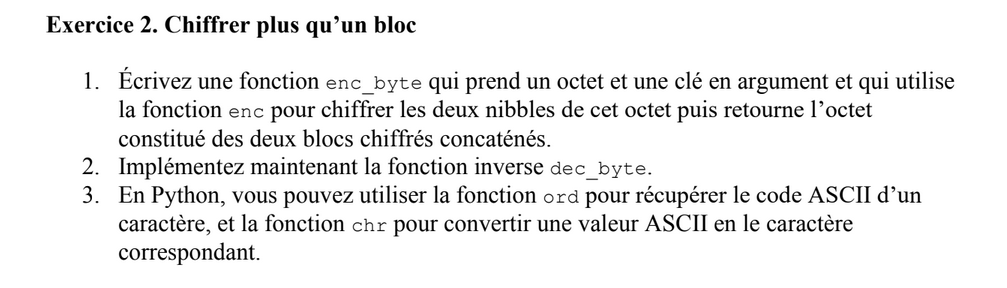

In [20]:
b=0b10101100

In [18]:
def enc_byte(b,k):
  b0=(b >> 4) & 0b1111
  b1= b & 0b1111
  c0=enc(b0,k)
  c1=enc(b1,k)
  return (c0 << 4) | c1

In [22]:
b

172

In [23]:
enc_byte(b,0b11110000)

200

In [24]:
def enc_inv(c,k):
  k0,k1=keys(k)
  r2=sbox.index(c)
  sr1=r2 ^ k1
  r1=sbox.index(sr1)
  m=r1 ^ k0
  return m

In [27]:
enc_inv(enc(10,255),255)

10

In [28]:
def enc_byte_inv(c,k):
  c0=(c >> 4) & 0b1111
  c1= c & 0b1111
  b0=enc_inv(c0,k)
  b1=enc_inv(c1,k)
  return (b0 << 4) | b1


In [29]:
enc_byte_inv(enc_byte(141,255),255)

141

In [34]:
text="TEST"
c=''
for i in text:
  c1=enc_byte(ord(i),254)
  c=c+chr(c1)


In [35]:
c

'Z¥_Z'